<a href="https://colab.research.google.com/github/SonghanWu/latent-message-handoff/blob/main/notebooks/latent_message.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
REPO = "https://github.com/SonghanWu/latent-message-handoff.git"
if not os.path.exists("latent-message-handoff"):
    print("Cloning repository...")
    subprocess.run(["git", "clone", "-q", REPO], check=True)
if os.path.exists("latent-message-handoff") and os.path.basename(os.getcwd()) != "latent-message-handoff":
    os.chdir("latent-message-handoff")
if IN_COLAB:
    print("Installing requirements...")
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "-r", "requirements.txt"], check=True)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
import torch
print("cwd:", os.getcwd())
print("cuda:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

Cloning repository...
Installing requirements...
cwd: /content/latent-message-handoff
cuda: True Tesla T4


In [2]:
import sys
import os

# Ensure we are in the correct repository folder and add it to sys.path
repo_dir = "/content/latent-message-handoff"
if os.path.exists(repo_dir):
    if os.getcwd() != repo_dir:
        os.chdir(repo_dir)
    if repo_dir not in sys.path:
        sys.path.insert(0, repo_dir)

from latent_comm.model_io import load_lm
from latent_comm.kvcache import cache_bytes, scalars_per_token, to_legacy
MODEL = "Qwen/Qwen2.5-0.5B-Instruct"   # swap for Qwen2.5-1.5B-Instruct to check scale
lm = load_lm(MODEL)
cfg_model = lm.config
print(f"{MODEL}: {cfg_model.num_hidden_layers} layers, "
      f"{cfg_model.num_attention_heads} query heads, {cfg_model.num_key_value_heads} KV heads, "
      f"head_dim {cfg_model.hidden_size // cfg_model.num_attention_heads}")

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen/Qwen2.5-0.5B-Instruct: 24 layers, 14 query heads, 2 KV heads, head_dim 64


In [3]:
from latent_comm.model_io import prefill_with_attention
probe = lm.encode(" ".join(["the quick brown fox jumps over the lazy dog."] * 40))
probe_cache, probe_attn = prefill_with_attention(lm, probe)
k0, v0 = to_legacy(probe_cache)[0]
n_tok = probe.shape[1]
per_tok = scalars_per_token(probe_cache)
print(f"document tokens          : {n_tok}")
print(f"per-layer key tensor     : {tuple(k0.shape)}   (batch, kv_heads, seq, head_dim)")
print(f"scalars per token        : {per_tok}  = 2 x {cfg_model.num_hidden_layers} layers "
      f"x {cfg_model.num_key_value_heads} kv heads x {cfg_model.hidden_size // cfg_model.num_attention_heads}")
print(f"bytes per token (fp16)   : {per_tok * 2:,}")
print(f"whole cache              : {cache_bytes(probe_cache) / 1024:,.0f} KiB")
print(f"at a 32k context         : {per_tok * 2 * 32768 / 1024**2:,.0f} MiB")

document tokens          : 400
per-layer key tensor     : (1, 2, 400, 64)   (batch, kv_heads, seq, head_dim)
scalars per token        : 6144  = 2 x 24 layers x 2 kv heads x 64
bytes per token (fp16)   : 12,288
whole cache              : 4,800 KiB
at a 32k context         : 384 MiB


In [4]:
from latent_comm.data import load_examples, render_and_tokenize, choose_side_info
examples = load_examples(n=100, seed=0)
ex = examples[0]
tex = render_and_tokenize(lm, ex)
print(f"question : {ex.question}")
print(f"answer   : {ex.answer}")
print(f"paragraphs: {len(ex.paragraphs)}  (gold: {ex.gold_idx})")
print(f"document : {tex.doc_len} tokens")
print(f"full cache for this document: {tex.doc_len * scalars_per_token(probe_cache) * 2 / 1024:,.0f} KiB")

README.md:   0%|          | 0.00/9.52k [00:00<?, ?B/s]

distractor/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  166MB            

distractor/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

distractor/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  166MB            

distractor/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

distractor/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 27.5MB            

distractor/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

question : Alexander Kerensky was defeated and destroyed by the Bolsheviks in the course of a civil war that ended when ?
answer   : October 1922
paragraphs: 10  (gold: [0, 7])
document : 1946 tokens
full cache for this document: 23,352 KiB


receiver already holds paragraphs: [1, 2, 3, 5, 6, 8]  | gold: [0, 7]


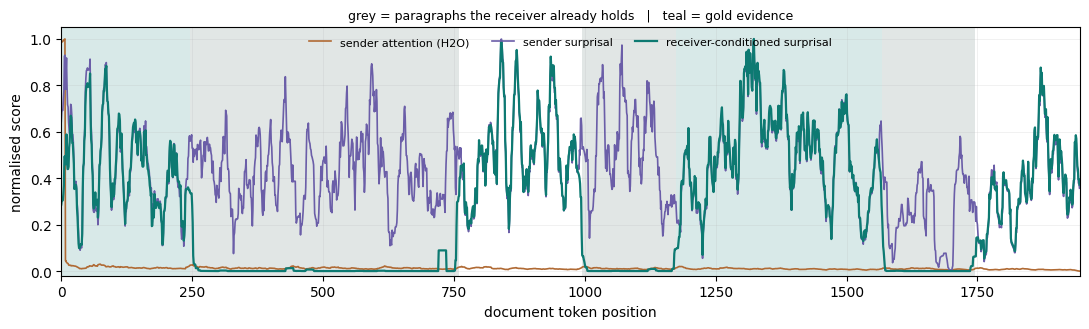

In [5]:
from latent_comm.model_io import token_surprisal
from latent_comm.experiment import render_side_info
from latent_comm.stats import plot_scores

SIDE_LEVEL = 6
side_paras = choose_side_info(tex, SIDE_LEVEL, seed=0)
cache_full, attn_score = prefill_with_attention(lm, tex.doc_ids)
sender_sup = token_surprisal(lm, lm.encode(f"Question: {ex.question}\n\n"), tex.doc_ids)
receiver_sup = token_surprisal(
    lm,
    lm.encode(render_side_info(ex, side_paras) + f"Question: {ex.question}\n\n"),
    tex.doc_ids,
)
os.makedirs("results", exist_ok=True)
_ = plot_scores(tex, attn_score, sender_sup, receiver_sup, side_paras, "results/scores.png")
print("receiver already holds paragraphs:", side_paras, " | gold:", ex.gold_idx)

In [6]:
import os, sys, importlib
print("cwd:", os.getcwd())
print("latent_comm 在不在:", os.path.exists("latent_comm/__init__.py"))
print("sys.path[0]:", sys.path[0])
for m in ["torch", "transformers", "datasets", "pandas", "numpy", "matplotlib"]:
    try:
        mod = importlib.import_module(m)
        print(f"  {m:14s} {getattr(mod, '__version__', '?')}")
    except Exception as e:
        print(f"  {m:14s} MISSING -- {type(e).__name__}: {e}")

cwd: /content/latent-message-handoff
latent_comm 在不在: True
sys.path[0]: /content/latent-message-handoff
  torch          2.11.0+cu128
  transformers   5.16.1
  datasets       4.8.5
  pandas         2.2.3
  numpy          2.1.3
  matplotlib     3.10.0


In [7]:
from latent_comm.experiment import Config, run
from latent_comm.stats import to_frame

cfg = Config(
    model_name=MODEL,
    n_examples=len(examples),
    side_info_levels=(0, 3, 6),
    budget_fractions=(0.05, 0.10, 0.20),
    seed=0,
    out_dir="results",
)
rows = run(lm, examples, cfg)
df = to_frame(rows)
print(len(df), "rows")
df.head()

4500 rows


,qid,example_index,doc_len,side_level,n_side_positions,budget_frac,budget,rule,nll,nll_full_cache,nll_side_only,wasted_budget,transmitted_scalars,cache_bytes_after_merge
0,5abf63f15542997ec76fd3ea,0,1946,0,0,0.05,97,random,1.331925,1.485424,1.679372,0,595968,1597440
1,5abf63f15542997ec76fd3ea,0,1946,0,0,0.05,97,sender_attention,2.447976,1.485424,1.679372,0,595968,1597440
2,5abf63f15542997ec76fd3ea,0,1946,0,0,0.05,97,sender_surprisal,1.880602,1.485424,1.679372,0,595968,1597440
3,5abf63f15542997ec76fd3ea,0,1946,0,0,0.05,97,dedup_sender_surprisal,1.880602,1.485424,1.679372,0,595968,1597440
4,5abf63f15542997ec76fd3ea,0,1946,0,0,0.05,97,receiver_surprisal,1.880602,1.485424,1.679372,0,595968,1597440


side_level,0,3,6
rule,,,
dedup_sender_surprisal,3.0168,3.1377,2.8884
random,3.4123,3.9585,4.1005
receiver_surprisal,3.0168,3.1260,2.9093
sender_attention,3.9018,4.1651,4.1485
sender_surprisal,3.0168,3.4017,3.5440


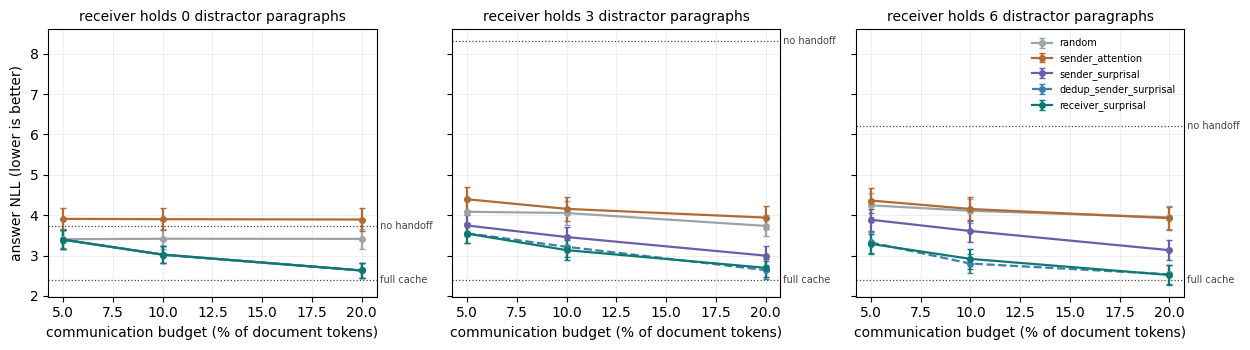

In [9]:
from latent_comm.stats import main_figure
_ = main_figure(df, "results/main.png")
df.pivot_table(index="rule", columns="side_level", values="nll").round(4)

In [11]:
from latent_comm.stats import comparison_table
comparisons = comparison_table(df)
comparisons.to_csv("results/comparisons.csv", index=False)
comparisons.round(4)

,side_level,budget_frac,comparison,delta_nll,ci_lo,ci_hi,n,significant
0,0,0.05,receiver_surprisal - sender_attention,-0.5147,-0.8457,-0.1949,100,True
1,0,0.05,receiver_surprisal - sender_surprisal,0.0000,0.0000,0.0000,100,False
2,0,0.05,receiver_surprisal - dedup_sender_surprisal,0.0000,0.0000,0.0000,100,False
3,0,0.05,dedup_sender_surprisal - sender_surprisal,0.0000,0.0000,0.0000,100,False
4,0,0.10,receiver_surprisal - sender_attention,-0.8782,-1.2536,-0.5105,100,True
5,0,0.10,receiver_surprisal - sender_surprisal,0.0000,0.0000,0.0000,100,False
6,0,0.10,receiver_surprisal - dedup_sender_surprisal,0.0000,0.0000,0.0000,100,False
7,0,0.10,dedup_sender_surprisal - sender_surprisal,0.0000,0.0000,0.0000,100,False
8,0,0.20,receiver_surprisal - sender_attention,-1.2621,-1.6846,-0.8544,100,True
9,0,0.20,receiver_surprisal - sender_surprisal,0.0000,0.0000,0.0000,100,False


In [14]:
from latent_comm.stats import interaction_test

interaction = interaction_test(df, "receiver_surprisal", "dedup_sender_surprisal")
interaction.to_csv("results/interaction.csv", index=False)
interaction.round(4)

,budget_frac,side_low,side_high,delta_at_low,delta_at_high,difference_of_differences,ci_lo,ci_hi,n
0,0.05,0,6,0.0,-0.0361,-0.0361,-0.1344,0.0536,100
1,0.10,0,6,0.0,0.1153,0.1153,-0.0221,0.2846,100
2,0.20,0,6,0.0,-0.0166,-0.0166,-0.0738,0.0373,100


In [15]:
# How much of each rule's budget went to content the receiver already had.df[df.side_level == 6].pivot_table(    index="rule", columns="budget_frac", values="wasted_budget").round(1)

In [17]:
from latent_comm.experiment import save_reference_tensors

save_reference_tensors(lm, examples[0], cfg, "results/reference_tensors.pt")
blob = torch.load("results/reference_tensors.pt", weights_only=False)
print("keys:", list(blob.keys()))
print("layers saved:", blob["layer_ids"])
print("key tensor shape per layer:", tuple(blob["kv"][0][0].shape))
print("accumulated attention shape:", tuple(blob["accumulated_attention"].shape))
print("\nresults/score_tensors.pt additionally holds, for the first 3 questions:")
print("  accumulated attention, sender surprisal, receiver surprisal per side level,")
print("  the side-information positions, and every rule's selected position set.")

keys: ['model', 'qid', 'question', 'answer', 'doc_ids', 'para_spans', 'gold_idx', 'layer_ids', 'kv', 'accumulated_attention']
layers saved: [0, 12, 23]
key tensor shape per layer: (1, 2, 1946, 64)
accumulated attention shape: (1946,)

results/score_tensors.pt additionally holds, for the first 3 questions:
  accumulated attention, sender surprisal, receiver surprisal per side level,
  the side-information positions, and every rule's selected position set.


In [18]:
!zip -qr results.zip results
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>